# **Trabalho 2 - EEL891: Introdução ao Aprendizado de Máquina**

## 1. Importação das bibliotecas

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Coleta de Dados

In [18]:
df_train = pd.read_csv("data/conjunto_de_treinamento.csv")
df_test = pd.read_csv("data/conjunto_de_teste.csv")
print(list(df_train.columns))

['Id', 'tipo', 'bairro', 'tipo_vendedor', 'quartos', 'suites', 'vagas', 'area_util', 'area_extra', 'diferenciais', 'churrasqueira', 'estacionamento', 'piscina', 'playground', 'quadra', 's_festas', 's_jogos', 's_ginastica', 'sauna', 'vista_mar', 'preco']


In [19]:
df_train.head()

,Id,tipo,bairro,tipo_vendedor,quartos,suites,vagas,area_util,area_extra,diferenciais,...,estacionamento,piscina,playground,quadra,s_festas,s_jogos,s_ginastica,sauna,vista_mar,preco
0,2000,Casa,Imbiribeira,Imobiliaria,3,3,5,223,167,piscina e copa,...,0,1,0,0,0,0,0,0,0,1000000.0
1,2001,Apartamento,Casa Amarela,Imobiliaria,4,4,2,157,0,piscina e churrasqueira,...,0,1,0,0,0,0,0,0,0,680000.0
2,2002,Apartamento,Encruzilhada,Imobiliaria,3,1,0,53,0,nenhum,...,0,0,0,0,0,0,0,0,0,450000.0
3,2003,Apartamento,Boa Viagem,Imobiliaria,4,3,2,149,0,piscina e churrasqueira,...,0,1,0,0,0,0,0,0,0,1080000.0
4,2004,Apartamento,Rosarinho,Imobiliaria,2,1,1,54,0,piscina e churrasqueira,...,0,1,0,0,0,0,0,0,0,350000.0


In [20]:
df_test.head()

,Id,tipo,bairro,tipo_vendedor,quartos,suites,vagas,area_util,area_extra,diferenciais,churrasqueira,estacionamento,piscina,playground,quadra,s_festas,s_jogos,s_ginastica,sauna,vista_mar
0,0,Apartamento,Pina,Imobiliaria,4,4,3,182,0,copa e playground,0,0,0,1,0,0,0,0,0,0
1,1,Apartamento,Tamarineira,Imobiliaria,2,0,1,85,0,nenhum,0,0,0,0,0,0,0,0,0,0
2,2,Apartamento,Boa Viagem,Imobiliaria,3,1,2,115,20,piscina e churrasqueira,1,0,1,0,0,0,0,0,0,0
3,3,Apartamento,Iputinga,Imobiliaria,3,0,1,92,0,nenhum,0,0,0,0,0,0,0,0,0,0
4,4,Apartamento,Engenho do Meio,Imobiliaria,3,1,1,65,0,piscina e copa,0,0,1,0,0,0,0,0,0,0


In [21]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4683 entries, 0 to 4682
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Id              4683 non-null   int64  
 1   tipo            4683 non-null   object 
 2   bairro          4683 non-null   object 
 3   tipo_vendedor   4683 non-null   object 
 4   quartos         4683 non-null   int64  
 5   suites          4683 non-null   int64  
 6   vagas           4683 non-null   int64  
 7   area_util       4683 non-null   int64  
 8   area_extra      4683 non-null   int64  
 9   diferenciais    4683 non-null   object 
 10  churrasqueira   4683 non-null   int64  
 11  estacionamento  4683 non-null   int64  
 12  piscina         4683 non-null   int64  
 13  playground      4683 non-null   int64  
 14  quadra          4683 non-null   int64  
 15  s_festas        4683 non-null   int64  
 16  s_jogos         4683 non-null   int64  
 17  s_ginastica     4683 non-null   i

In [22]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Id              2000 non-null   int64 
 1   tipo            2000 non-null   object
 2   bairro          2000 non-null   object
 3   tipo_vendedor   2000 non-null   object
 4   quartos         2000 non-null   int64 
 5   suites          2000 non-null   int64 
 6   vagas           2000 non-null   int64 
 7   area_util       2000 non-null   int64 
 8   area_extra      2000 non-null   int64 
 9   diferenciais    2000 non-null   object
 10  churrasqueira   2000 non-null   int64 
 11  estacionamento  2000 non-null   int64 
 12  piscina         2000 non-null   int64 
 13  playground      2000 non-null   int64 
 14  quadra          2000 non-null   int64 
 15  s_festas        2000 non-null   int64 
 16  s_jogos         2000 non-null   int64 
 17  s_ginastica     2000 non-null   int64 
 18  sauna   

## 3. Tratamento dos Dados

In [23]:
# Combina os dois DataFrames
df = pd.concat([df_train, df_test], ignore_index=True)
df.head()

,Id,tipo,bairro,tipo_vendedor,quartos,suites,vagas,area_util,area_extra,diferenciais,...,estacionamento,piscina,playground,quadra,s_festas,s_jogos,s_ginastica,sauna,vista_mar,preco
0,2000,Casa,Imbiribeira,Imobiliaria,3,3,5,223,167,piscina e copa,...,0,1,0,0,0,0,0,0,0,1000000.0
1,2001,Apartamento,Casa Amarela,Imobiliaria,4,4,2,157,0,piscina e churrasqueira,...,0,1,0,0,0,0,0,0,0,680000.0
2,2002,Apartamento,Encruzilhada,Imobiliaria,3,1,0,53,0,nenhum,...,0,0,0,0,0,0,0,0,0,450000.0
3,2003,Apartamento,Boa Viagem,Imobiliaria,4,3,2,149,0,piscina e churrasqueira,...,0,1,0,0,0,0,0,0,0,1080000.0
4,2004,Apartamento,Rosarinho,Imobiliaria,2,1,1,54,0,piscina e churrasqueira,...,0,1,0,0,0,0,0,0,0,350000.0


In [24]:
# Aplicando One-Hot Encoding do Tipo
df = pd.get_dummies(df, columns=['tipo'], prefix='tipo',dtype=int)
df.head()

,Id,bairro,tipo_vendedor,quartos,suites,vagas,area_util,area_extra,diferenciais,churrasqueira,...,s_festas,s_jogos,s_ginastica,sauna,vista_mar,preco,tipo_Apartamento,tipo_Casa,tipo_Loft,tipo_Quitinete
0,2000,Imbiribeira,Imobiliaria,3,3,5,223,167,piscina e copa,0,...,0,0,0,0,0,1000000.0,0,1,0,0
1,2001,Casa Amarela,Imobiliaria,4,4,2,157,0,piscina e churrasqueira,1,...,0,0,0,0,0,680000.0,1,0,0,0
2,2002,Encruzilhada,Imobiliaria,3,1,0,53,0,nenhum,0,...,0,0,0,0,0,450000.0,1,0,0,0
3,2003,Boa Viagem,Imobiliaria,4,3,2,149,0,piscina e churrasqueira,1,...,0,0,0,0,0,1080000.0,1,0,0,0
4,2004,Rosarinho,Imobiliaria,2,1,1,54,0,piscina e churrasqueira,1,...,0,0,0,0,0,350000.0,1,0,0,0


In [25]:
# Aplicando One-Hot Encoding do Bairro
df = pd.get_dummies(df, columns=['bairro'], prefix='bairro',dtype=int)
df.head()

,Id,tipo_vendedor,quartos,suites,vagas,area_util,area_extra,diferenciais,churrasqueira,estacionamento,...,bairro_Setubal,bairro_Soledade,bairro_Sto Amaro,bairro_Sto Antonio,bairro_Tamarineira,bairro_Tejipio,bairro_Torre,bairro_Torreao,bairro_Varzea,bairro_Zumbi
0,2000,Imobiliaria,3,3,5,223,167,piscina e copa,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2001,Imobiliaria,4,4,2,157,0,piscina e churrasqueira,1,0,...,0,0,0,0,0,0,0,0,0,0
2,2002,Imobiliaria,3,1,0,53,0,nenhum,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2003,Imobiliaria,4,3,2,149,0,piscina e churrasqueira,1,0,...,0,0,0,0,0,0,0,0,0,0
4,2004,Imobiliaria,2,1,1,54,0,piscina e churrasqueira,1,0,...,0,0,0,0,0,0,0,0,0,0


In [26]:
# Substitui 'Imobiliaria' por 1 e 'Pessoa Fisica' por 0 na coluna 'tipo_vendedor'
df['tipo_vendedor'] = df['tipo_vendedor'].map({'Imobiliaria': 1, 'Pessoa Fisica': 0})
print(df['tipo_vendedor'].dtype)
df.head()

int64


,Id,tipo_vendedor,quartos,suites,vagas,area_util,area_extra,diferenciais,churrasqueira,estacionamento,...,bairro_Setubal,bairro_Soledade,bairro_Sto Amaro,bairro_Sto Antonio,bairro_Tamarineira,bairro_Tejipio,bairro_Torre,bairro_Torreao,bairro_Varzea,bairro_Zumbi
0,2000,1,3,3,5,223,167,piscina e copa,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2001,1,4,4,2,157,0,piscina e churrasqueira,1,0,...,0,0,0,0,0,0,0,0,0,0
2,2002,1,3,1,0,53,0,nenhum,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2003,1,4,3,2,149,0,piscina e churrasqueira,1,0,...,0,0,0,0,0,0,0,0,0,0
4,2004,1,2,1,1,54,0,piscina e churrasqueira,1,0,...,0,0,0,0,0,0,0,0,0,0


In [27]:
df.drop(columns=['diferenciais'], inplace=True)
df.head()

,Id,tipo_vendedor,quartos,suites,vagas,area_util,area_extra,churrasqueira,estacionamento,piscina,...,bairro_Setubal,bairro_Soledade,bairro_Sto Amaro,bairro_Sto Antonio,bairro_Tamarineira,bairro_Tejipio,bairro_Torre,bairro_Torreao,bairro_Varzea,bairro_Zumbi
0,2000,1,3,3,5,223,167,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,2001,1,4,4,2,157,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
2,2002,1,3,1,0,53,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2003,1,4,3,2,149,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
4,2004,1,2,1,1,54,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0


In [28]:
df.columns

Index(['Id', 'tipo_vendedor', 'quartos', 'suites', 'vagas', 'area_util',
       'area_extra', 'churrasqueira', 'estacionamento', 'piscina',
       'playground', 'quadra', 's_festas', 's_jogos', 's_ginastica', 'sauna',
       'vista_mar', 'preco', 'tipo_Apartamento', 'tipo_Casa', 'tipo_Loft',
       'tipo_Quitinete', 'bairro_Aflitos', 'bairro_Afogados',
       'bairro_Agua Fria', 'bairro_Apipucos', 'bairro_Areias', 'bairro_Arruda',
       'bairro_Barro', 'bairro_Beberibe', 'bairro_Beira Rio', 'bairro_Benfica',
       'bairro_Boa Viagem', 'bairro_Boa Vista', 'bairro_Bongi',
       'bairro_Cajueiro', 'bairro_Campo Grande', 'bairro_Casa Amarela',
       'bairro_Casa Forte', 'bairro_Caxanga', 'bairro_Centro',
       'bairro_Cid Universitaria', 'bairro_Coelhos', 'bairro_Cohab',
       'bairro_Cordeiro', 'bairro_Derby', 'bairro_Dois Irmaos',
       'bairro_Encruzilhada', 'bairro_Engenho do Meio', 'bairro_Espinheiro',
       'bairro_Estancia', 'bairro_Fundao', 'bairro_Gracas', 'bairro_Guabirab

C:\Users\Lucas\AppData\Local\Temp\ipykernel_22056\3779498824.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlation_with_price.values, y=correlation_with_price.index, palette='coolwarm')


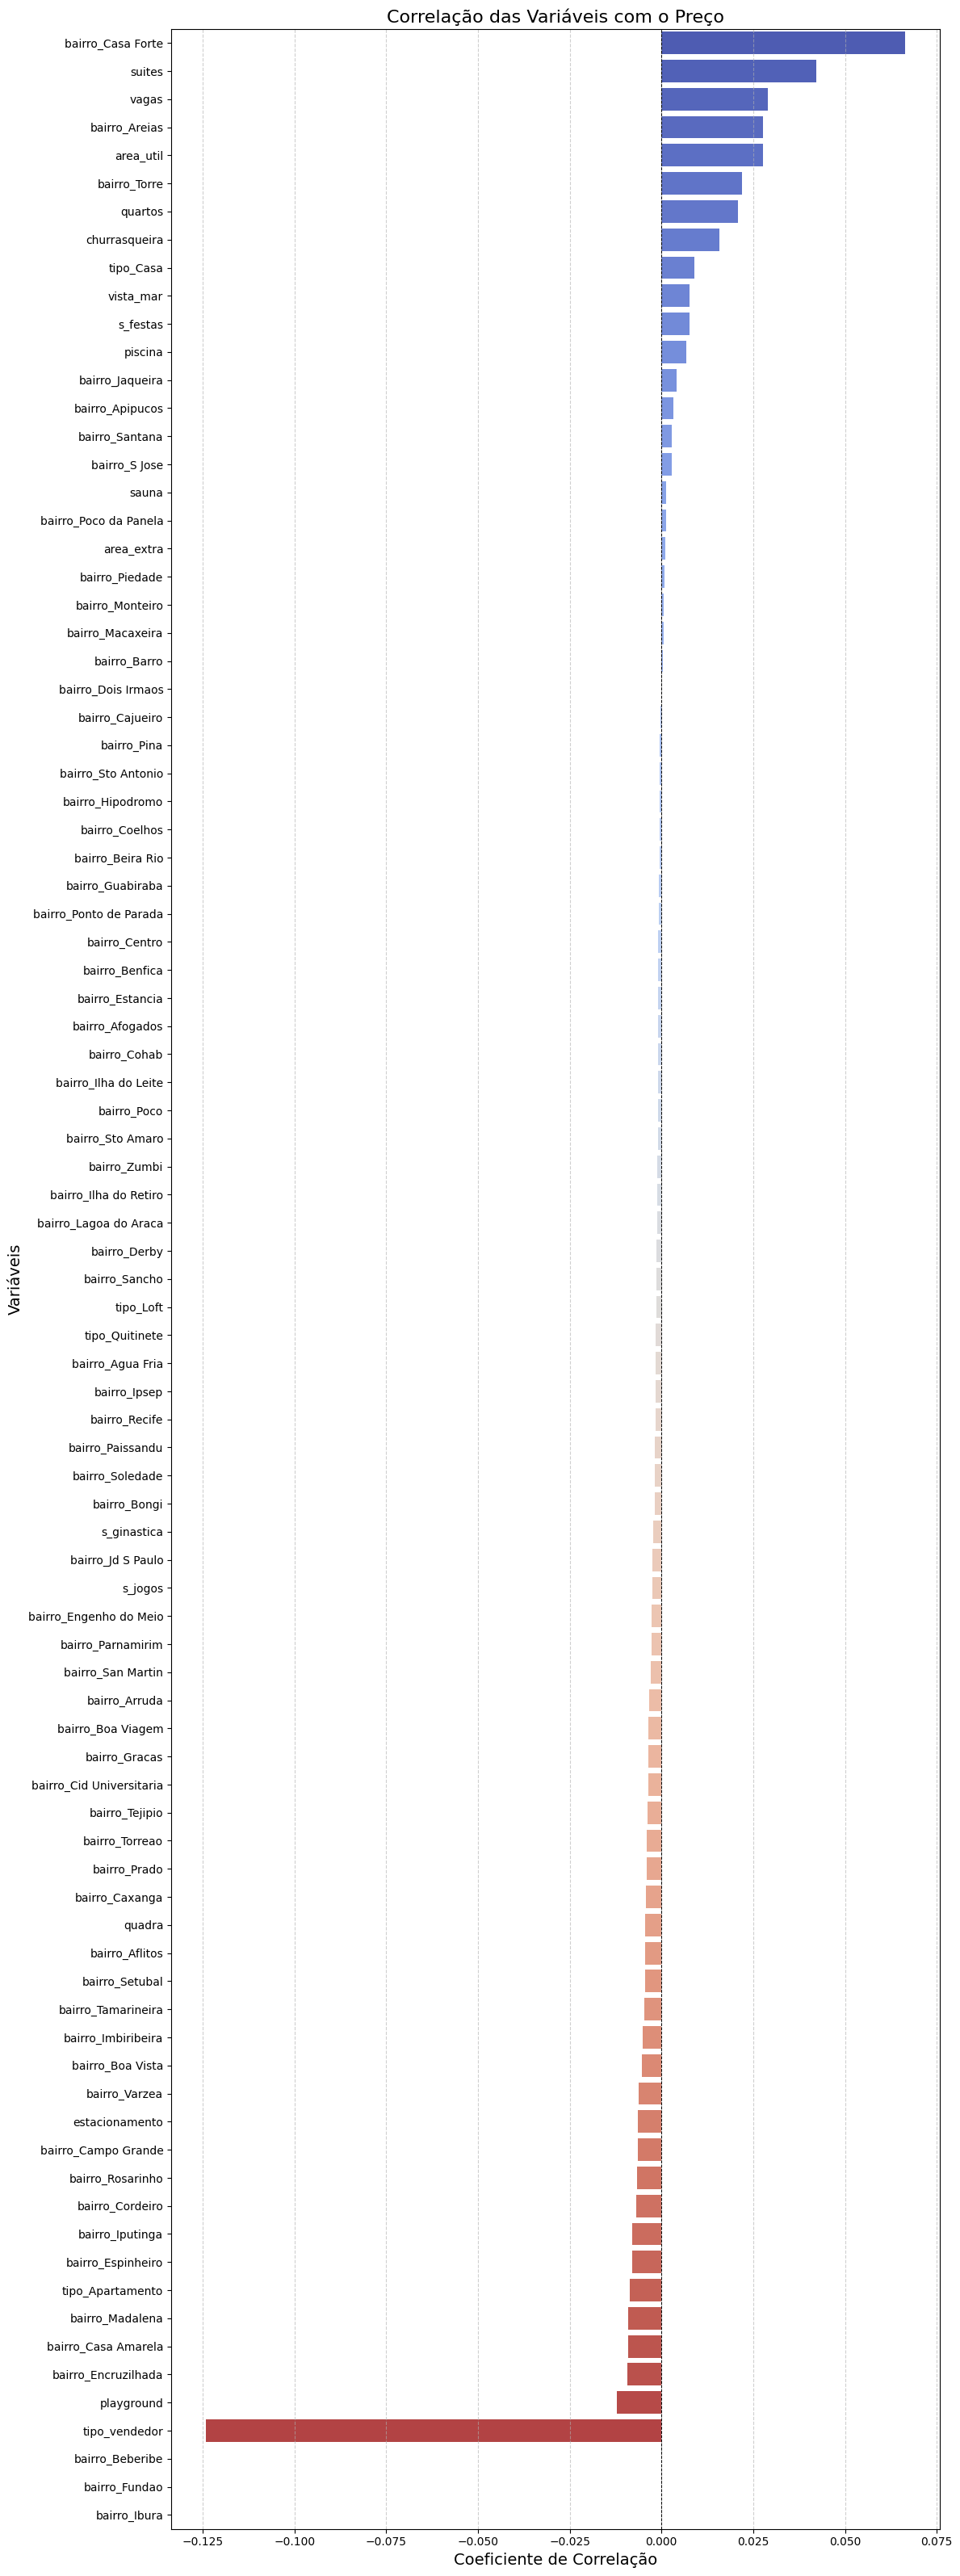

In [29]:
# Calcula a matriz de correlação e seleciona apenas as correlações com a coluna 'preco'
correlation_with_price = df.corr()['preco'].sort_values(ascending=False)

# Remove a correlação de 'preco' com ele mesmo (que é sempre 1) e exclui a coluna 'Id' se existir
columns_to_exclude = ['preco', 'Id']
correlation_with_price = correlation_with_price[~correlation_with_price.index.isin(columns_to_exclude)]

# Configura o gráfico de barras
plt.figure(figsize=(12, 32))
sns.barplot(x=correlation_with_price.values, y=correlation_with_price.index, palette='coolwarm')

# Adiciona rótulos e título
plt.title('Correlação das Variáveis com o Preço', fontsize=16)
plt.xlabel('Coeficiente de Correlação', fontsize=14)
plt.ylabel('Variáveis', fontsize=14)
plt.axvline(0, color='black', linestyle='--', linewidth=0.7)  # Linha indicando correlação nula

# Adiciona a grade
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, GridSearchCV
import numpy as np

# Separar os dados onde 'preco' não é NA e os que são
df_preco = df[df['preco'].notna()]
df_answer = df[df['preco'].isna()]

# Divisão em train e test (80% para train, 20% para test)
train, test = train_test_split(df_preco, test_size=0.2, random_state=42)

# Identificar colunas numéricas para calcular a correlação
numerical_columns = train.select_dtypes(include=[np.number]).columns

# Calcular a correlação com a variável 'preco'
correlation_matrix = train[numerical_columns].corr()
correlation_with_target = correlation_matrix['preco'].drop('preco').sort_values(ascending=False)

# Selecionar features com correlação relevante (positiva ou negativa)
threshold = 0.005
selected_features = correlation_with_target[
    (correlation_with_target >= threshold) | (correlation_with_target <= -threshold)
].index.tolist()

# Remover a coluna Id das features selecionadas (se existir)
if 'Id' in selected_features:
    selected_features.remove('Id')

print("Features selecionadas:", selected_features)

# Preparar os datasets para o modelo
X_train = train[selected_features]
y_train = train['preco']

X_test = test[selected_features]
y_test = test['preco']

# Configurando modelos e hiperparâmetros para GridSearchCV
models_and_params = {
    'RandomForest': (RandomForestRegressor(random_state=42), {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }),
    'GradientBoosting': (GradientBoostingRegressor(random_state=42), {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 1.0]
    }),
    'HistGradientBoosting': (HistGradientBoostingRegressor(random_state=42), {
        'max_iter': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [None, 10, 20],
        'min_samples_leaf': [10, 20, 30],
        'l2_regularization': [0.0, 0.1, 1.0],
    }),
    'LinearRegression': (LinearRegression(), {}),
    'Ridge': (Ridge(), {
        'alpha': [0.1, 1.0, 10.0, 100.0],
        'solver': ['auto', 'saga', 'cholesky']
    }),
    'Lasso': (Lasso(), {
        'alpha': [0.01, 0.1, 1.0, 10.0],
        'max_iter': [1000, 5000, 10000]
    }),
    'SVR': (SVR(), {
        'kernel': ['linear', 'rbf', 'poly'],
        'C': [0.1, 1.0, 10.0, 100.0],
        'epsilon': [0.01, 0.1, 1.0]
    })
}

# Melhor modelo e hiperparâmetros
best_model = None
best_score = -np.inf  # Para R², maior é melhor
best_name = ""
best_params = {}

# Realizando GridSearchCV para cada modelo
for name, (model, params) in models_and_params.items():
    print(f"\nTreinando {name} com GridSearchCV...")
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=params,
        scoring='r2',
        cv=3,
        n_jobs=-1,
        verbose=1
    )
    grid_search.fit(X_train, y_train)
    
    print(f"Melhor R² para {name}: {grid_search.best_score_}")
    print(f"Melhores parâmetros para {name}: {grid_search.best_params_}")
    
    if grid_search.best_score_ > best_score:
        best_model = grid_search.best_estimator_
        best_score = grid_search.best_score_
        best_name = name
        best_params = grid_search.best_params_

# Avaliar o melhor modelo no conjunto de teste
y_test_pred = best_model.predict(X_test)
test_r2 = best_model.score(X_test, y_test)

print(f"\nMelhor modelo: {best_name}")
print(f"Melhores parâmetros: {best_params}")
print(f"Desempenho no teste - R²: {test_r2}")

Features selecionadas: ['bairro_Casa Forte', 'suites', 'bairro_Areias', 'vagas', 'bairro_Torre', 'area_util', 'churrasqueira', 'quartos', 'playground', 'tipo_vendedor']

Treinando RandomForest com GridSearchCV...
Fitting 3 folds for each of 144 candidates, totalling 432 fits
Melhor R² para RandomForest: -0.9575985890152457
Melhores parâmetros para RandomForest: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 500}

Treinando GradientBoosting com GridSearchCV...
Fitting 3 folds for each of 54 candidates, totalling 162 fits
Melhor R² para GradientBoosting: -2.3611173702096706
Melhores parâmetros para GradientBoosting: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}

Treinando HistGradientBoosting com GridSearchCV...
Fitting 3 folds for each of 243 candidates, totalling 729 fits
Melhor R² para HistGradientBoosting: -0.14231310810094935
Melhores parâmetros para HistGradientBoosting: {'l2_regularization': 1.0, 'learning_rate': 0

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, rmspe

# Função para calcular o RMSPE
def rmspe(y_true, y_pred):
    percentage_error = ((y_true - y_pred) / y_true) ** 2
    return np.sqrt(np.mean(percentage_error))

# Avaliar o modelo no conjunto de teste
y_pred = best_model.predict(X_test)

# Calcular métricas de desempenho
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
test_rmspe = rmspe(y_test, y_pred)

print("\nMétricas de avaliação no conjunto de teste:")
print(f"R²: {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSPE: {test_rmspe:.4f}")


Métricas de avaliação no conjunto de teste:
R²: -591.0778
MSE: 200875492366091.8125
MAE: 10715591.7079
RMSPE: 23.7602


c:\Python312\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(


In [38]:
from datetime import datetime

# Aplicar o modelo no conjunto 'answer'
X_answer = df_answer[selected_features]
df_answer_result = df_answer[['Id']].copy()
df_answer_result['preco'] = best_model.predict(X_answer)

# Gerar timestamp para o nome do arquivo
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
file_name = f"data/resposta_final_{timestamp}.csv"

# Salvar a resposta final
df_answer_result.to_csv(file_name, index=False)

print(f"\nArquivo '{file_name}' salvo com as predições para o conjunto answer.")


Arquivo 'data/resposta_final_20241209_202134.csv' salvo com as predições para o conjunto answer.


c:\Python312\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(
